In [4]:
%pip install matplotlib

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path("../student_resource/datasets/student_resource/student_resource/dataset")

TRAIN_S1 = BASE / "train" / "train_source1.tsv"
TRAIN_S2 = BASE / "train" / "train_source2.tsv"
TRAIN_S3 = BASE / "train" / "train_source3.tsv"
TRAIN_GT = BASE / "train" / "train_ground_truth.tsv"
TEST_S1 = BASE / "test" / "test_source1.tsv"

SRC_COLS = ["entity_id", "business_name", "business_address", "country"]

SAMPLE_N = 200_000
RS = 42

print("BASE:", BASE.resolve())
for p in [TRAIN_S1, TRAIN_S2, TRAIN_S3, TRAIN_GT, TEST_S1]:
    # Try the configured path and common alternatives (including one fewer
    # duplicated "student_resource" directory).
    candidates = [
        BASE,
        BASE.parent / "dataset",
        BASE.parent.parent / "dataset",
    ]

    for root in [Path.cwd(), *Path.cwd().parents]:
        candidates.extend([
            root / "student_resource" / "datasets" / "student_resource" / "student_resource" / "dataset",
            root / "student_resource" / "datasets" / "student_resource" / "dataset",
            root / "student_resource" / "dataset",
        ])

    BASE = next(
        (candidate for candidate in candidates
         if (candidate / "train" / "train_source1.tsv").is_file()),
        None,
    )

    if BASE is None:
        raise FileNotFoundError(
            "Could not find train/train_source1.tsv. Check the dataset location "
            f"(current working directory: {Path.cwd()})."
        )

    TRAIN_S1 = BASE / "train" / "train_source1.tsv"
    TRAIN_S2 = BASE / "train" / "train_source2.tsv"
    TRAIN_S3 = BASE / "train" / "train_source3.tsv"
    TRAIN_GT = BASE / "train" / "train_ground_truth.tsv"
    TEST_S1 = BASE / "test" / "test_source1.tsv"

    print("BASE:", BASE.resolve())
    for p in [TRAIN_S1, TRAIN_S2, TRAIN_S3, TRAIN_GT, TEST_S1]:
        print(p.exists(), f"{p.stat().st_size / 1e6:.1f}MB" if p.exists() else "missing", p)


Note: you may need to restart the kernel to use updated packages.
BASE: D:\Coding Files\Hacakathon\ml-challenge\student_resource\datasets\student_resource\student_resource\dataset
BASE: D:\Coding Files\Hacakathon\ml-challenge\student_resource\dataset
True 210.1MB d:\Coding Files\Hacakathon\ml-challenge\student_resource\dataset\train\train_source1.tsv
True 489.3MB d:\Coding Files\Hacakathon\ml-challenge\student_resource\dataset\train\train_source2.tsv
True 503.7MB d:\Coding Files\Hacakathon\ml-challenge\student_resource\dataset\train\train_source3.tsv
True 127.0MB d:\Coding Files\Hacakathon\ml-challenge\student_resource\dataset\train\train_ground_truth.tsv
True 175.0MB d:\Coding Files\Hacakathon\ml-challenge\student_resource\dataset\test\test_source1.tsv
BASE: D:\Coding Files\Hacakathon\ml-challenge\student_resource\dataset
True 210.1MB d:\Coding Files\Hacakathon\ml-challenge\student_resource\dataset\train\train_source1.tsv
True 489.3MB d:\Coding Files\Hacakathon\ml-challenge\student_re

In [5]:
def quick_profile(path, label, n_missing_sample=200_000):
    df = pd.read_csv(path, sep="\t", dtype="string", keep_default_na=True)
    print(f"\n=== {label}: {path.name} ===")
    print("shape:", df.shape, "| cols:", list(df.columns))
    print(df.dtypes.to_string())
    print("missing:\n", df.isna().sum().to_string())
    print("empty-string:\n", ((df == "").sum(numeric_only=False)).to_string())
    print("dup entity_id:", int(df[df.columns[0]].duplicated().sum()))
    s = df.sample(n=min(n_missing_sample, len(df)), random_state=RS) if len(df) else df
    print("sampled full-row dups:", int(s.duplicated().sum()))
    return df

s1 = quick_profile(TRAIN_S1, "train_source1")
s2 = quick_profile(TRAIN_S2, "train_source2")
s3 = quick_profile(TRAIN_S3, "train_source3")
gt = pd.read_csv(TRAIN_GT, sep="\t", dtype="string", keep_default_na=False)
print("\n=== train_ground_truth ===")
print("shape:", gt.shape, "| cols:", list(gt.columns))
print("dup source1_entity_id:", int(gt["source1_entity_id"].duplicated().sum()))
print(gt.head(3).to_string())



=== train_source1: train_source1.tsv ===
shape: (2206821, 4) | cols: ['entity_id', 'business_name', 'business_address', 'country']
entity_id           string
business_name       string
business_address    string
country             string
missing:
 entity_id           0
business_name       0
business_address    0
country             0
empty-string:
 entity_id           0
business_name       0
business_address    0
country             0
dup entity_id: 0
sampled full-row dups: 0

=== train_source2: train_source2.tsv ===
shape: (5034616, 4) | cols: ['entity_id', 'business_name', 'business_address', 'country']
entity_id           string
business_name       string
business_address    string
country             string
missing:
 entity_id                0
business_name            2
business_address    168967
country                  0
empty-string:
 entity_id           0
business_name       0
business_address    0
country             0
dup entity_id: 0
sampled full-row dups: 0

=== train_sou


=== train_source1 (n=200000) ===
name_len:
 count    200000.0
mean     24.02431
std      7.719956
min           3.0
25%          18.0
50%          24.0
75%          30.0
max          87.0
addr_len:
 count     200000.0
mean     52.013765
std      25.307051
min           15.0
25%           33.0
50%           41.0
75%           70.0
max          217.0
unique names: 172444 | unique addrs: 198865
dup name rate: 0.1991
dup addr rate: 0.0109

=== train_source2 (n=200000) ===
name_len:
 count    200000.0
mean     25.09863
std      8.877766
min           2.0
25%          19.0
50%          25.0
75%          31.0
max          92.0
addr_len:
 count     200000.0
mean      46.32913
std      24.890147
min            0.0
25%           30.0
50%           37.0
75%           62.0
max          219.0
unique names: 195688 | unique addrs: 192298
dup name rate: 0.0378
dup addr rate: 0.0439

=== train_source3 (n=200000) ===
name_len:
 count     200000.0
mean     25.156065
std       9.479549
min            0.0

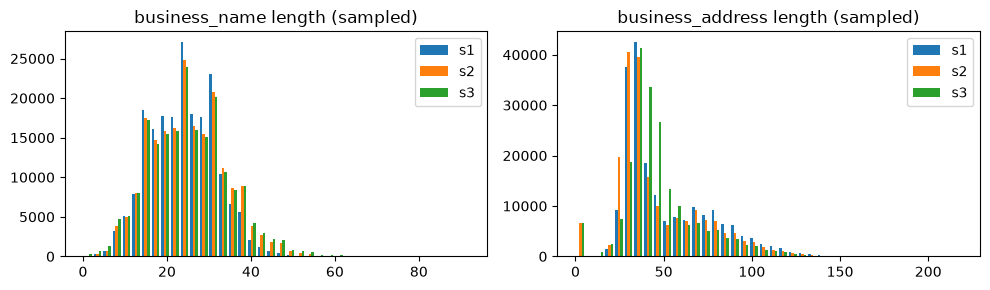

In [6]:
def text_stats(df, label, n=SAMPLE_N):
    s = df.sample(n=min(n, len(df)), random_state=RS) if len(df) > n else df
    name_len = s["business_name"].fillna("").str.len()
    addr_len = s["business_address"].fillna("").str.len()
    print(f"\n=== {label} (n={len(s)}) ===")
    print("name_len:\n", name_len.describe().to_string())
    print("addr_len:\n", addr_len.describe().to_string())
    print("unique names:", s["business_name"].nunique(), "| unique addrs:", s["business_address"].nunique())
    print("dup name rate:", (s["business_name"].duplicated(keep=False).mean()).round(4))
    print("dup addr rate:", (s["business_address"].duplicated(keep=False).mean()).round(4))
    return name_len, addr_len

n1, a1 = text_stats(s1, "train_source1")
n2, a2 = text_stats(s2, "train_source2")
n3, a3 = text_stats(s3, "train_source3")

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].hist([n1, n2, n3], bins=40, label=["s1", "s2", "s3"])
ax[0].set_title("business_name length (sampled)"); ax[0].legend()
ax[1].hist([a1, a2, a3], bins=40, label=["s1", "s2", "s3"])
ax[1].set_title("business_address length (sampled)"); ax[1].legend()
plt.tight_layout(); plt.show()



train_s1:
 country
US       1323633
India     883188

train_s2:
 country
US       3016817
India    2017799

train_s3:
 country
US       3170056
India    2115547

test_s1:
 country
India     809986
US        663106
France    259452


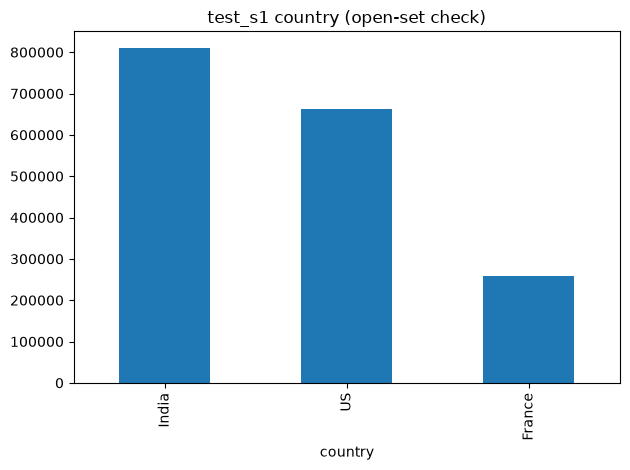

In [7]:
for label, df in [("train_s1", s1), ("train_s2", s2), ("train_s3", s3)]:
    print(f"\n{label}:\n", df["country"].value_counts(dropna=False).to_string())

te1_small = pd.read_csv(TEST_S1, sep="\t", dtype="string", usecols=["entity_id", "country"])
print("\ntest_s1:\n", te1_small["country"].value_counts(dropna=False).to_string())
te1_small["country"].value_counts().plot(kind="bar", title="test_s1 country (open-set check)")
plt.tight_layout(); plt.show()
del te1_small


matches per S1:
 count    2.206821e+06
mean     3.461253e+00
std      1.705323e+00
min      0.000000e+00
25%      2.000000e+00
50%      3.000000e+00
75%      5.000000e+00
max      1.100000e+01
singleton (0-match) rate: 0.0558

match-count histogram:
 0     123247
1     119157
2     375212
3     530841
4     484115
5     321957
6     164868
7      63968
8      18680
9       4205
10       534
11        37

S2-count per S1:
 count    2206821.0
mean      1.673728
std       1.112813
min            0.0
25%            1.0
50%            2.0
75%            2.0
max            5.0

S3-count per S1:
 count    2206821.0
mean      1.787524
std       1.165604
min            0.0
25%            1.0
50%            2.0
75%            3.0
max            6.0

has-any-S2: 0.8696 | has-any-S3: 0.8793 | has-both: 0.8048 | S2-only: 0.0648 | S3-only: 0.0745


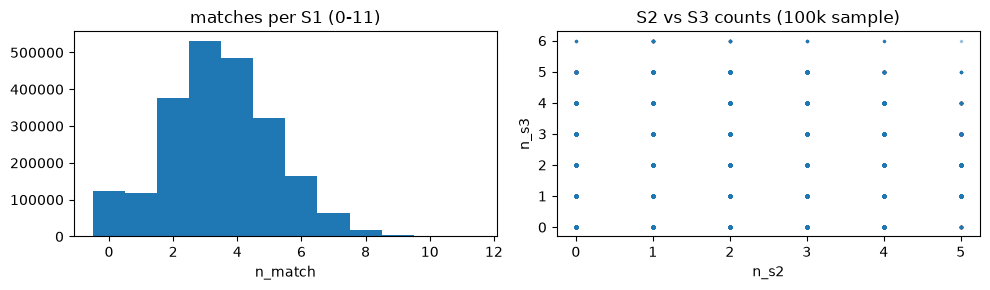

In [8]:
m = gt["matched_entity_ids"].fillna("")
is_empty = (m == "")
n_match = pd.Series(np.where(is_empty, 0, m.str.count(",") + 1), index=gt.index)
n_s2 = m.str.count("S2-")
n_s3 = m.str.count("S3-")
print("matches per S1:\n", n_match.describe().to_string())
print("singleton (0-match) rate:", round(float((n_match == 0).mean()), 4))
print("\nmatch-count histogram:\n", n_match.value_counts().sort_index().head(15).to_string())
print("\nS2-count per S1:\n", n_s2.describe().to_string())
print("\nS3-count per S1:\n", n_s3.describe().to_string())
print("\nhas-any-S2:", round(float((n_s2 > 0).mean()), 4),
      "| has-any-S3:", round(float((n_s3 > 0).mean()), 4),
      "| has-both:", round(float(((n_s2 > 0) & (n_s3 > 0)).mean()), 4),
      "| S2-only:", round(float(((n_s2 > 0) & (n_s3 == 0) & (n_match > 0)).mean()), 4),
      "| S3-only:", round(float(((n_s3 > 0) & (n_s2 == 0) & (n_match > 0)).mean()), 4))

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].hist(n_match[n_match <= 11], bins=range(13), align="left")
ax[0].set_title("matches per S1 (0-11)"); ax[0].set_xlabel("n_match")
ax[1].scatter(n_s2.sample(min(100_000, len(n_s2)), random_state=RS),
              n_s3.sample(min(100_000, len(n_s3)), random_state=RS), s=2, alpha=0.2)
ax[1].set_title("S2 vs S3 counts (100k sample)"); ax[1].set_xlabel("n_s2"); ax[1].set_ylabel("n_s3")
plt.tight_layout(); plt.show()


In [9]:
K = 5
cand = gt.loc[n_match > 0, ["source1_entity_id", "matched_entity_ids"]].sample(
    n=K, random_state=RS)

s1_idx = s1.set_index("entity_id")
s2_idx = s2.set_index("entity_id")
s3_idx = s3.set_index("entity_id")

for _, row in cand.iterrows():
    sid, mids = row["source1_entity_id"], str(row["matched_entity_ids"]).split(",")[:6]
    print("=" * 100)
    print("S1:", sid)
    if sid in s1_idx.index:
        print("  S1 row:", s1_idx.loc[sid, ["business_name", "business_address", "country"]].to_dict())
    for mid in mids:
        src = s2_idx if mid.startswith("S2-") else s3_idx
        if mid in src.index:
            print(f"  {mid}:", src.loc[mid, ["business_name", "business_address", "country"]].to_dict())
        else:
            print(f"  {mid}: <not in loaded frame>")


S1: S1-777210964
  S1 row: {'business_name': 'Davis Family Office', 'business_address': '88 Olive Circle, Lebanon, TN', 'country': 'US'}
  S2-12029274: {'business_name': 'Davis Family Offie', 'business_address': '88 OLIVE CIR, LEBANON, TN', 'country': 'US'}
  S2-407524980: {'business_name': 'DAVIS FAMILY OFFICE', 'business_address': 'OLIVE CIR, LEBANON, TN', 'country': 'US'}
  S3-970714334: {'business_name': 'Davis Family (Office)', 'business_address': '88 Olive Cir, Lebanon, Tennessee', 'country': 'US'}
  S3-712922821: {'business_name': 'Davis Family', 'business_address': 'Lebanon, Tennessee, 88 Olive Cir', 'country': 'US'}
S1: S1-190133982
  S1 row: {'business_name': 'MS Consultancy Corp', 'business_address': 'Shymala Appts 1St Floor Flat No. 4 Opp Ratna Hospital Sb Road In Haveli, Pune, Maharashtra', 'country': 'India'}
  S2-523219173: {'business_name': 'MS [Consultancy]', 'business_address': 'SHYMALA APPTS 1-1ST FLOOR FLAT NO. 4 OPP RATNA HOSPITAL SB ROAD IN HAVELI, PUNE, Maharasht

pairs: 2000
        name_exact  name_jaccard     name_seq  addr_jaccard     addr_seq
count  2000.000000   2000.000000  2000.000000   2000.000000  2000.000000
mean      0.202500      0.597269     0.772194      0.648796     0.773083
std       0.401963      0.339153     0.286133      0.260450     0.225781
min       0.000000      0.000000     0.000000      0.000000     0.000000
25%       0.000000      0.428571     0.714286      0.500000     0.677237
50%       0.000000      0.666667     0.875000      0.666667     0.846154
75%       0.000000      1.000000     0.959178      0.857143     0.931034
max       1.000000      1.000000     1.000000      1.000000     1.000000

name exact-match rate: 0.2025


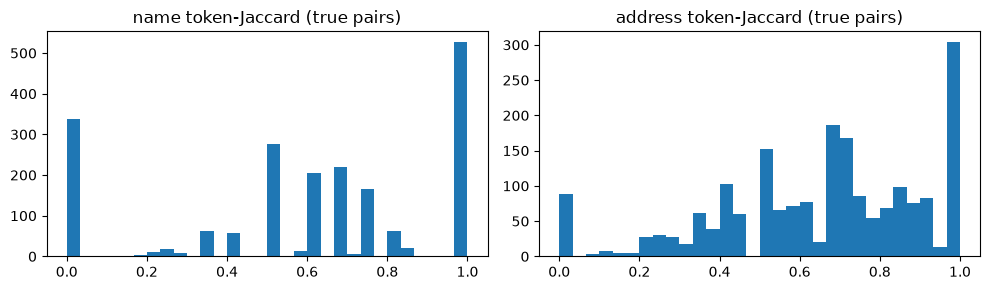

In [10]:
import re
from difflib import SequenceMatcher

def norm(x):
    x = str(x).lower()
    x = re.sub(r"[^a-z0-9 ]", " ", x)
    return re.sub(r"\s+", " ", x).strip()

def tok_jaccard(a, b):
    sa, sb = set(a.split()), set(b.split())
    return len(sa & sb) / len(sa | sb) if (sa | sb) else 1.0

N_PAIRS = 2000
gt_s = gt.loc[n_match > 0].sample(n=min(N_PAIRS, int((n_match > 0).sum())), random_state=RS)
rows = []
for _, r in gt_s.iterrows():
    sid = r["source1_entity_id"]
    if sid not in s1_idx.index:
        continue
    s1r = s1_idx.loc[sid]
    for mid in str(r["matched_entity_ids"]).split(",")[:2]:
        src = s2_idx if mid.startswith("S2-") else s3_idx
        if mid not in src.index:
            continue
        cr = src.loc[mid]
        nn1, nn2 = norm(s1r["business_name"]), norm(cr["business_name"])
        na1, na2 = norm(s1r["business_address"]), norm(cr["business_address"])
        rows.append({
            "name_exact": int(nn1 == nn2),
            "name_jaccard": tok_jaccard(nn1, nn2),
            "name_seq": SequenceMatcher(None, nn1, nn2).ratio(),
            "addr_jaccard": tok_jaccard(na1, na2),
            "addr_seq": SequenceMatcher(None, na1, na2).ratio(),
            "src": "S2" if mid.startswith("S2-") else "S3",
        })
        if len(rows) >= N_PAIRS:
            break
    if len(rows) >= N_PAIRS:
        break

sim = pd.DataFrame(rows)
print("pairs:", len(sim))
print(sim.describe().to_string())
print("\nname exact-match rate:", round(float(sim["name_exact"].mean()), 4) if len(sim) else None)
if len(sim):
    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    ax[0].hist(sim["name_jaccard"], bins=30); ax[0].set_title("name token-Jaccard (true pairs)")
    ax[1].hist(sim["addr_jaccard"], bins=30); ax[1].set_title("address token-Jaccard (true pairs)")
    plt.tight_layout(); plt.show()


In [11]:
print(f"S1 train={len(s1):,} | S2={len(s2):,} | S3={len(s3):,} | GT rows={len(gt):,}")
print(f"singleton rate={(n_match == 0).mean():.4f} | mean matches={n_match[n_match > 0].mean():.2f} (non-singleton)")
print("Implications: F0.5 is precision-heavy -> tune threshold high; keep singleton path;")
print("country is open-set (test adds France) -> no hard-coded US/India filter, use per-country or normalized blocking;")
print("blocking must cover both S2 and S3 (has-both/S2-only/S3-only printed in §4);")
print("name/addr noise (abbr, suffixes, transliteration) -> normalized token-Jaccard + char-sim features (§6).")


S1 train=2,206,821 | S2=5,034,616 | S3=5,285,603 | GT rows=2,206,821
singleton rate=0.0558 | mean matches=3.67 (non-singleton)
Implications: F0.5 is precision-heavy -> tune threshold high; keep singleton path;
country is open-set (test adds France) -> no hard-coded US/India filter, use per-country or normalized blocking;
blocking must cover both S2 and S3 (has-both/S2-only/S3-only printed in §4);
name/addr noise (abbr, suffixes, transliteration) -> normalized token-Jaccard + char-sim features (§6).
